In [49]:
# import libraries
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

In pytorch , we can do Convulutions by using the nn.conv2d class 


In [50]:
#create an instance of conv2d class


conv = nn.Conv2d(
    in_channels=1,   # grayscale = 1, RGB = 3
    out_channels=8,  # number of filters
    kernel_size=3,
    stride=1,
    padding=0
)
'''
in_channels=1    →   your image 
out_channels=8   →   8 different filters → 8 feature maps
kernel_size=3    →   3x3 kernel
stride=1         →   move 1 pixel
padding=0        →   keep size same

'''
print(conv)




Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))


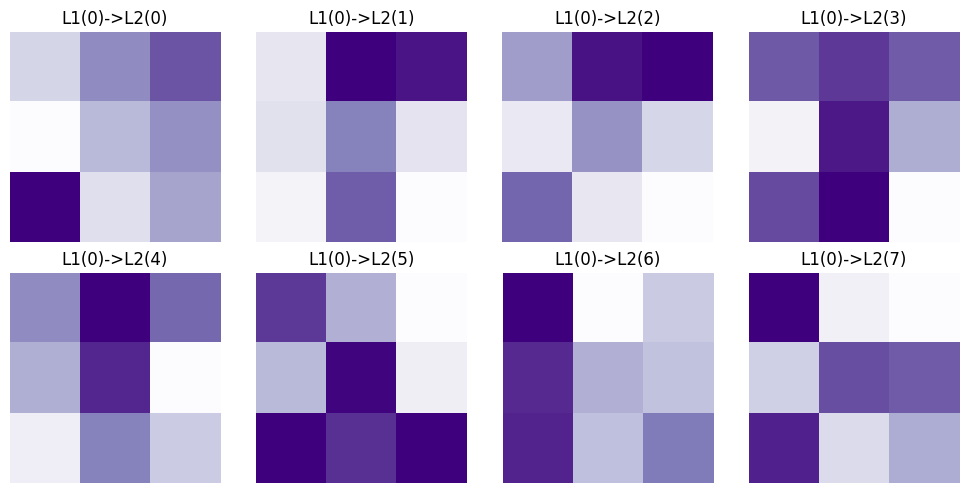

In [51]:
# What do these kernels look like?

fig,axs = plt.subplots(2,4,figsize=(10,5))

for i,ax in enumerate(axs.flatten()):
  ax.imshow(torch.squeeze(conv.weight[i,0,:,:]).detach(),cmap='Purples')
  ax.set_title('L1(0)->L2(%s)'%i)
  ax.axis('off')

plt.tight_layout()
plt.show()

(512, 512)


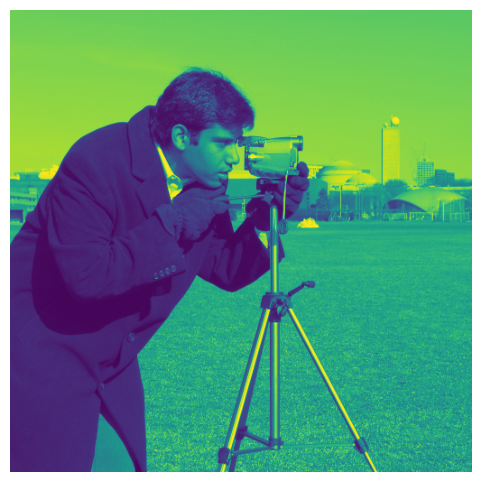

In [52]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Use a sample image from scikit-image instead of trying to open a file
bathtub = data.camera()

# convert to numpy
bathtub = np.array(bathtub)

# check size
print(bathtub.shape)

# display
plt.figure(figsize=(10,6))
plt.imshow(bathtub)
plt.axis('off')
plt.show()



In [53]:
# convert to tensor
bathtub_tensor = torch.tensor(bathtub, dtype=torch.float32)

# add batch + channel dimensions
bathtub_tensor = bathtub_tensor.unsqueeze(0).unsqueeze(0)
conv_image = conv(bathtub_tensor)

print(bathtub_tensor.shape)
print(conv_image.shape)

torch.Size([1, 1, 512, 512])
torch.Size([1, 8, 510, 510])


This means the Input image had size of (512 , 512) with 1 colour channel (greyscale image) 

The output image has 8 output channels i.e 8 filters has 8 outputs and the image size is (510 ,510)

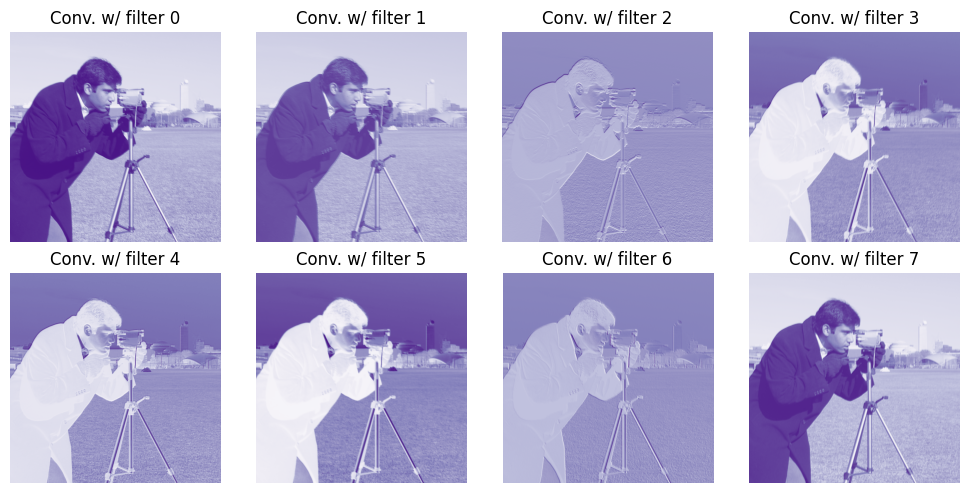

In [54]:
# What do the convolved images look like? (Hint: think of the bathtub picture.)

fig,axs = plt.subplots(2,4,figsize=(10,5))

for i,ax in enumerate(axs.flatten()):

  # extract this "layer" of the convolution result
  I = torch.squeeze(conv_image[0,i,:,:]).detach()

  # and visualize it
  ax.imshow(I,cmap='Purples')
  ax.set_title('Conv. w/ filter %s'%i)
  ax.axis('off')

plt.tight_layout()
plt.show()